In [19]:
import subprocess
import sys

def install_if_missing(package):
    """Check if package is installed, if not install it."""
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install packages
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('pylab')
install_if_missing('IPython')
install_if_missing('astropy')
install_if_missing('scipy')
install_if_missing('tqdm')
install_if_missing('ipywidgets')


# Now import them
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from astropy.coordinates import get_body_barycentric_posvel, GCRS, SkyCoord, ICRS, Galactic, GeocentricMeanEcliptic
from astropy.time import Time
import astropy.units as u
from scipy.interpolate import interp1d

import time
import math
import os
from datetime import datetime   
from tqdm.notebook import tqdm
import ipywidgets as widgets

import pylab as py
from IPython.display import HTML

In [2]:
class Body:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = position
        self.velocity = velocity

    def copy(self):
        return Body(self.mass, self.position[:], self.velocity[:])

In [3]:
#parameters
G = 6.673e-11 #N m^2 / kg^2
M_Earth  = 6.0e24
M_Sun = 1.989e30 #kg
M_Moon =  7.342e22 #kg
M_oculus = 1500 #kg
M_lux = 500 #kg

R_earth = 6371e3 #m
R_orbit = 91e6+R_earth #m

d_spacecraft = 68.46 #m
orientation_polar = 0    * math.pi / 180 # radians
orientation_azimuthal = 0 * math.pi / 180 # radians

v_spacecraft_0 = math.sqrt(G*M_Earth/R_orbit) # m/s
T_orbit = 2*math.pi*R_orbit/v_spacecraft_0
T_orbit_hours = T_orbit / 3600
T_orbit_days = T_orbit_hours / 24

orbit_inclination = 51.6 * math.pi / 180 # radians

N_steps = 2000
dt = T_orbit / N_steps
t = np.linspace(0, T_orbit, N_steps)

# ─── J2 ─────────────────────────────────────────────────────
J2        = 1.08263e-3           # Earth J2 coefficient
mu        = G * M_Earth          # gravitational parameter [m^3/s^2]

# ─── SRP ─────────────────────────────────────────────────────
P_solar   = 4.56e-6              # N/m^2  solar radiation pressure at 1 AU
AU        = 149597870700      # m
C_R       = 1.5                  # reflectivity coefficient
A_sc      = 1.0                  # m^2  cross-sectional area
m_sc      = 500.0                # kg   (same as M_oculus / M_lux)

# ─── Epoch for ephemeris ─────────────────────────────────────
# Set this to your simulation start date/time
t0_epoch  = Time("2025-01-01T00:00:00", scale="utc")

In [4]:
print(f"Orbital period: {T_orbit_hours:.2f} hours ({T_orbit_days:.2f} days)")

Orbital period: 83.81 hours (3.49 days)


In [5]:
D = 45.4
e = 200*1e-6 
pointing_accuracy = np.atan(e/D) * 180 / math.pi * 3600 # arcseconds
print(f"Pointing accuracy: {pointing_accuracy:.2f} arcseconds")

Pointing accuracy: 0.91 arcseconds


In [6]:
def get_sun_moon_eci(t_sec):
    """
    Return Sun and Moon ECI positions [m] at t_sec seconds after t0_epoch.
    Uses astropy JPL ephemeris (built-in 'erfa' kernel — no extra download needed).
    """
    t = t0_epoch + t_sec * u.s

    # --- Sun ---
    sun_gcrs  = get_body_barycentric_posvel('sun', t, ephemeris='builtin')[0]
    # Transform barycentric to geocentric
    sun_coord = SkyCoord(sun_gcrs, frame='icrs', obstime=t, representation_type='cartesian')
    sun_coord = sun_coord.transform_to(GCRS(obstime=t))
    r_sun     = np.array([sun_coord.cartesian.x.to(u.m).value,
                           sun_coord.cartesian.y.to(u.m).value,
                           sun_coord.cartesian.z.to(u.m).value])

    # --- Moon ---
    moon_gcrs  = get_body_barycentric_posvel('moon', t, ephemeris='builtin')[0]
    moon_coord = SkyCoord(moon_gcrs, frame='icrs', obstime=t, representation_type='cartesian')
    moon_coord = moon_coord.transform_to(GCRS(obstime=t))
    r_moon     = np.array([moon_coord.cartesian.x.to(u.m).value,
                            moon_coord.cartesian.y.to(u.m).value,
                            moon_coord.cartesian.z.to(u.m).value])
    return r_sun, r_moon

print("Pre-computing Sun/Moon ephemeris table...")
_sun_table  = np.zeros((N_steps, 3))
_moon_table = np.zeros((N_steps, 3))

# Sample every 100 steps to keep runtime short, then interpolate
sample_idx = np.arange(0, N_steps, 100)
_sun_samp  = np.zeros((len(sample_idx), 3))
_moon_samp = np.zeros((len(sample_idx), 3))

for k, idx in enumerate(sample_idx):
    _sun_samp[k], _moon_samp[k] = get_sun_moon_eci(t[idx])

_sun_interp  = interp1d(t[sample_idx], _sun_samp,  axis=0, fill_value="extrapolate")
_moon_interp = interp1d(t[sample_idx], _moon_samp, axis=0, fill_value="extrapolate")

def r_sun_at(t_sec):
    return _sun_interp(t_sec)

def r_moon_at(t_sec):
    return _moon_interp(t_sec)

print("Ephemeris table ready.")

Pre-computing Sun/Moon ephemeris table...
Ephemeris table ready.


In [7]:
def compute_perturbed_acceleration(position, t_sec=0.0):
    """
    Full perturbed acceleration [m/s^2] in ECI frame.

    Perturbations:
        - J2 oblateness
        - Sun third-body  (live astropy ephemeris)
        - Moon third-body (live astropy ephemeris)
        - Solar radiation pressure
    """
    r_sun  = r_sun_at(t_sec)
    r_moon = r_moon_at(t_sec)

    r_norm = np.linalg.norm(position)

    # ── 1. Two-body central ────────────────────────────────────────────────
    a_2body = -mu / r_norm**3 * position

    # ── 2. J2 ─────────────────────────────────────────────────────────────
    z2_r2  = (position[2] / r_norm) ** 2
    fJ2    = 1.5 * J2 * mu * R_earth**2 / r_norm**5
    a_J2   = fJ2 * np.array([
        position[0] * (5.0 * z2_r2 - 1.0),
        position[1] * (5.0 * z2_r2 - 1.0),
        position[2] * (5.0 * z2_r2 - 3.0)
    ])

    # ── 3. Sun third-body ─────────────────────────────────────────────────
    d_sun    = r_sun - position
    a_sun    = G * M_Sun  * (d_sun  / np.linalg.norm(d_sun)**3
                             - r_sun  / np.linalg.norm(r_sun)**3)

    # ── 4. Moon third-body ────────────────────────────────────────────────
    d_moon   = r_moon - position
    a_moon   = G * M_Moon * (d_moon / np.linalg.norm(d_moon)**3
                             - r_moon / np.linalg.norm(r_moon)**3)

    # ── 5. Solar Radiation Pressure ───────────────────────────────────────
    sc_from_sun      = position - r_sun
    sc_from_sun_norm = np.linalg.norm(sc_from_sun)
    sc_from_sun_hat  = sc_from_sun / sc_from_sun_norm
    P_scaled         = P_solar * (AU / sc_from_sun_norm) ** 2
    a_srp            = (C_R * P_scaled * A_sc / m_sc) * sc_from_sun_hat

    return a_2body + a_J2 + a_sun + a_moon + a_srp, d_sun, d_moon

In [ ]:
def make_initial_conditions(polar_angle, inclination, d):
    r_oculus_0 = np.array([
        R_orbit * np.cos(inclination),
        0.0,
        R_orbit * np.sin(inclination)
    ])

    v_oculus_0 = np.array([
        0.0,
        v_spacecraft_0,
        0.0
    ])

    r_lux_0 = r_oculus_0 + np.array([
        d * np.cos(polar_angle) * np.cos(orientation_azimuthal),
        d * np.cos(polar_angle) * np.sin(orientation_azimuthal),
        d * np.sin(polar_angle)
    ])

    v_lux_0 = v_oculus_0.copy()

    orbital_normal_vector = np.array([
        -np.sin(inclination),
        0.0,
        np.cos(inclination)
    ])

    return r_oculus_0, v_oculus_0, r_lux_0, v_lux_0, orbital_normal_vector


In [9]:
class Simulation:
    def __init__(self, body1, body2, dt, nsteps, gravity_func):
        self.body1        = body1
        self.body2        = body2
        self.dt           = dt
        self.nsteps       = nsteps
        self.gravity_func = gravity_func
        self.sun_relative_temp = 0
        self.moon_relative_temp = 0

        self.relative_offset = self.body2.position.copy() - self.body1.position.copy()

        self.r1 = np.zeros((nsteps, 3))
        self.v1 = np.zeros((nsteps, 3))
        self.r2 = np.zeros((nsteps, 3))
        self.v2 = np.zeros((nsteps, 3))
        self.f2_constraint = np.zeros((nsteps, 3))
        self.sun_relative = np.zeros((nsteps, 3))
        self.moon_relative = np.zeros((nsteps, 3))

        self.total_impulse = 0.0
        self.has_run       = False
        self._store_step(0)

    def _store_step(self, i):
        self.r1[i] = self.body1.position
        self.v1[i] = self.body1.velocity
        self.r2[i] = self.body2.position
        self.v2[i] = self.body2.velocity

    def _rk4_step_with_constraint(self, step):
        dt = self.dt
        d0 = self.relative_offset

        r1_0 = self.body1.position.copy()
        v1_0 = self.body1.velocity.copy()

        def acc(r_vec):
            a, d_sun_temp, d_moon_temp = self.gravity_func(r_vec, step*dt)
            return a
        # ---------- stage 1 ----------
        r1_s1 = r1_0
        v1_s1 = v1_0
        a1_s1 = acc(r1_s1)

        r2_s1 = r1_s1 + d0
        v2_s1 = v1_s1.copy()
        a2_grav_s1 = acc(r2_s1)
        a2_req_s1 = a1_s1.copy()
        a2_con_s1 = a2_req_s1 - a2_grav_s1

        k1_r = v1_s1
        k1_v = a1_s1

        # ---------- stage 2 ----------
        r1_s2 = r1_0 + 0.5 * dt * k1_r
        v1_s2 = v1_0 + 0.5 * dt * k1_v
        a1_s2 = acc(r1_s2)

        r2_s2 = r1_s2 + d0
        v2_s2 = v1_s2.copy()
        a2_grav_s2 = acc(r2_s2)
        a2_req_s2 = a1_s2.copy()
        a2_con_s2 = a2_req_s2 - a2_grav_s2

        k2_r = v1_s2
        k2_v = a1_s2

        # ---------- stage 3 ----------
        r1_s3 = r1_0 + 0.5 * dt * k2_r
        v1_s3 = v1_0 + 0.5 * dt * k2_v
        a1_s3 = acc(r1_s3)

        r2_s3 = r1_s3 + d0
        v2_s3 = v1_s3.copy()
        a2_grav_s3 = acc(r2_s3)
        a2_req_s3 = a1_s3.copy()
        a2_con_s3 = a2_req_s3 - a2_grav_s3

        k3_r = v1_s3
        k3_v = a1_s3

        # ---------- stage 4 ----------
        r1_s4 = r1_0 + dt * k3_r
        v1_s4 = v1_0 + dt * k3_v
        a1_s4 = acc(r1_s4)

        r2_s4 = r1_s4 + d0
        v2_s4 = v1_s4.copy()
        a2_grav_s4 = acc(r2_s4)
        a2_req_s4 = a1_s4.copy()
        a2_con_s4 = a2_req_s4 - a2_grav_s4

        k4_r = v1_s4
        k4_v = a1_s4

        # ---------- final RK4 update ----------
        r1_new = r1_0 + dt * (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0
        v1_new = v1_0 + dt * (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0

        a1_rk4 = (a1_s1 + 2*a1_s2 + 2*a1_s3 + a1_s4) / 6.0
        a2_total_rk4 = (a2_req_s1 + 2*a2_req_s2 + 2*a2_req_s3 + a2_req_s4) / 6.0
        a2_grav_rk4 = (a2_grav_s1 + 2*a2_grav_s2 + 2*a2_grav_s3 + a2_grav_s4) / 6.0
        a2_con_rk4 = (a2_con_s1 + 2*a2_con_s2 + 2*a2_con_s3 + a2_con_s4) / 6.0

        r2_new = r1_new + d0
        v2_new = v1_new.copy()

        self.body1.position = r1_new
        self.body1.velocity = v1_new
        self.body2.position = r2_new
        self.body2.velocity = v2_new

        return a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4

    def run(self, trim_start=0):
        for i in range(1, self.nsteps):
            a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4 = self._rk4_step_with_constraint(i)
            self._store_step(i)

            self.f2_constraint[i] = self.body2.mass * a2_con_rk4
            self.sun_relative[i] = self.sun_relative_temp
            self.moon_relative[i] = self.moon_relative_temp
            self.total_impulse   += np.linalg.norm(self.f2_constraint[i]) * self.dt

        if trim_start > 0:
            self.r1 = self.r1[trim_start:]
            self.v1 = self.v1[trim_start:]
            self.r2 = self.r2[trim_start:]
            self.v2 = self.v2[trim_start:]
            self.f2_constraint = self.f2_constraint[trim_start:]

        self.has_run = True

    # ── plotting / CSV methods unchanged ──────────────────────────────────
    
    def plot_trajectories(self):
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(self.r1[:, 0], self.r1[:, 1], self.r1[:, 2], label="Oculus")
        ax.plot(self.r2[:, 0], self.r2[:, 1], self.r2[:, 2], label="Lux")
        ax.scatter(0, 0, 0, color="gold", s=100, label="Earth")

        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_zlabel("Z Position (m)")
        ax.set_title("3D Trajectories")
        ax.legend()
        plt.show()

    def plot_solar_system(self):
        if not self.has_run:
            raise RuntimeError("Run simulation before plotting solar system")

        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

        # Earth at origin
        ax.scatter(0, 0, 0, color="blue", s=100, label="Earth")

        # Sun and Moon trajectories in Earth-centered coordinates
        ax.plot(
            self.sun_relative[:, 0],
            self.sun_relative[:, 1],
            self.sun_relative[:, 2],
            color="orange",
            label="Sun",
        )
        ax.plot(
            self.moon_relative[:, 0],
            self.moon_relative[:, 1],
            self.moon_relative[:, 2],
            color="gray",
            label="Moon",
        )

        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_zlabel("Z Position (m)")
        ax.set_title("Solar System Bodies Trajectories (Earth-centered)")
        ax.legend()
        plt.show()
    

    def plot_constraint_force(self):
        plt.figure(figsize=(10, 5))
        plt.plot(np.linalg.norm(self.f2_constraint, axis=1))
        plt.xlabel("Time Step")
        plt.ylabel("Constraint Force (N)")
        plt.title("Constraint Force Magnitude on Body 2")
        plt.grid(True)
        plt.show()
    
    def print_total_impulse(self):
        print(f"Total Impulse Exerted on Body 2: {self.total_impulse:.2e} N·s")
    
    def save_to_csv(self, filename):
        data = {
            "time": np.arange(len(self.r1)) * self.dt,
            "r1_x": self.r1[:, 0],
            "r1_y": self.r1[:, 1],
            "r1_z": self.r1[:, 2],
            "v1_x": self.v1[:, 0],
            "v1_y": self.v1[:, 1],
            "v1_z": self.v1[:, 2],
            "r2_x": self.r2[:, 0],
            "r2_y": self.r2[:, 1],
            "r2_z": self.r2[:, 2],
            "v2_x": self.v2[:, 0],
            "v2_y": self.v2[:, 1],
            "v2_z": self.v2[:, 2],
            "f2_constraint_x": self.f2_constraint[:, 0],
            "f2_constraint_y": self.f2_constraint[:, 1],
            "f2_constraint_z": self.f2_constraint[:, 2]
        }
        df = pd.DataFrame(data)
        df.to_csv(filename, index=False)



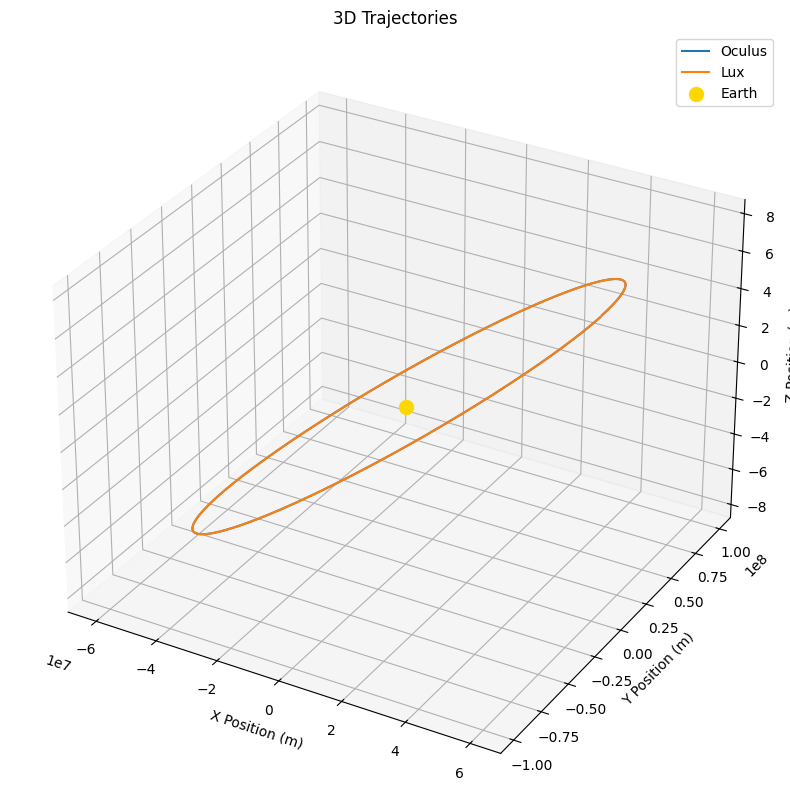

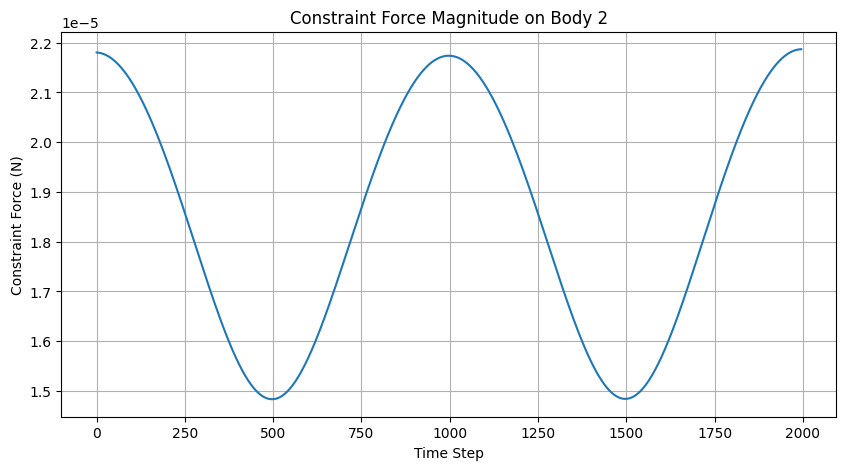

Total Impulse Exerted on Body 2: 5.57e+00 N·s


In [10]:
test_simulation = Simulation(
    Body(M_oculus, *make_initial_conditions(orientation_polar, orbit_inclination)[:2]),
    Body(M_lux, *make_initial_conditions(orientation_polar, orbit_inclination)[2:4]),
    dt,
    N_steps,
    compute_perturbed_acceleration
)
test_simulation.run(4)
test_simulation.plot_trajectories()
test_simulation.plot_constraint_force()
test_simulation.print_total_impulse()
test_simulation.save_to_csv("simulation_results_test.csv")

In [11]:
Map_resolution = 30
polar_angles = np.linspace(-90, 90, Map_resolution) * math.pi / 180
orbit_inclinations = np.linspace(0, 60, Map_resolution) * math.pi / 180

total_impulse_map = np.zeros((len(polar_angles), len(orbit_inclinations)))

for i, polar_angle in enumerate(
    tqdm(polar_angles, desc="Polar angle sweep", position=0, unit="angle", leave=True)
):
    for j, inclination in enumerate(
        tqdm(orbit_inclinations, desc="Orbit inclination sweep", position=1, unit="inclination", leave=True)
    ):
        r1_0, v1_0, r2_0, v2_0, orbital_normal_vector = make_initial_conditions(
            polar_angle, inclination
        )

        body1 = Body(M_oculus, r1_0.copy(), v1_0.copy())
        body2 = Body(M_lux, r2_0.copy(), v2_0.copy())

        sim = Simulation(body1, body2, dt, N_steps, compute_perturbed_acceleration)
        sim.run(trim_start=4)
        total_impulse_map[i, j] = sim.total_impulse

        del sim

# save the summary array separately
file_name = f"total_impulse_map_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npy"
np.save(file_name, total_impulse_map)
np.savetxt(
    file_name.replace(".npy", ".csv"),
    total_impulse_map,
    delimiter=","
)

# Optional: save the actual parameter values too
np.savetxt(
    file_name.replace(".npy", "_polar_angles_deg.csv"),

    np.degrees(polar_angles),
    delimiter=","
)
np.savetxt(
    file_name.replace(".npy", "_orbit_inclinations_deg.csv"),
    np.degrees(orbit_inclinations),
    delimiter=","
)


Polar angle sweep:   0%|          | 0/30 [00:00<?, ?angle/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

...

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

Orbit inclination sweep:   0%|          | 0/30 [00:00<?, ?inclination/s]

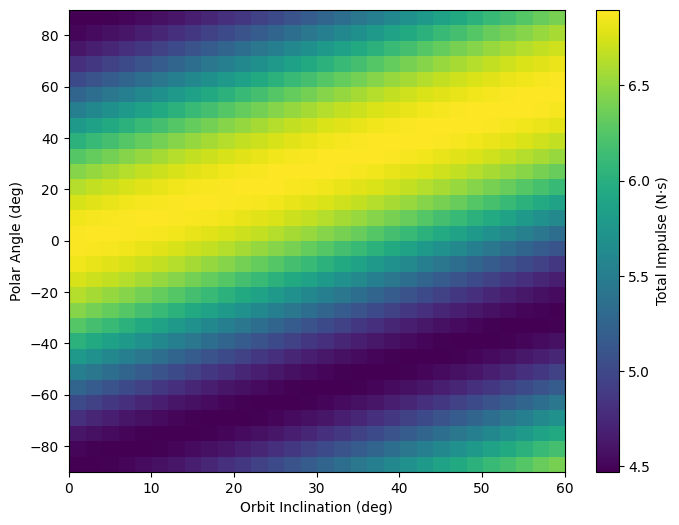

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(total_impulse_map, extent=[0, 60, -90, 90], aspect="auto", origin="lower")
plt.colorbar(label="Total Impulse (N·s)")
plt.xlabel("Orbit Inclination (deg)")   
plt.ylabel("Polar Angle (deg)")
plt.show()

In [20]:
def _unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

def get_galactic_center_gcrs(epoch):
    gc_icrs = SkyCoord(l=0*u.deg, b=0*u.deg, frame=Galactic()).transform_to(ICRS())
    gc_gcrs = gc_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(gc_gcrs.cartesian.xyz.to_value(u.one))

def get_north_galactic_pole_gcrs(epoch):
    ngp_icrs = SkyCoord(l=0*u.deg, b=90*u.deg, frame=Galactic()).transform_to(ICRS())
    ngp_gcrs = ngp_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(ngp_gcrs.cartesian.xyz.to_value(u.one))

def get_north_ecliptic_pole_gcrs(epoch):
    nep_icrs = SkyCoord(
        lon=0*u.deg,
        lat=90*u.deg,
        frame=GeocentricMeanEcliptic(equinox=epoch)
    ).transform_to(ICRS())
    nep_gcrs = nep_icrs.transform_to(GCRS(obstime=epoch))
    return _unit(nep_gcrs.cartesian.xyz.to_value(u.one))

In [22]:
r_gc_hat = get_galactic_center_gcrs(t0_epoch)
r_ngp_hat = get_north_galactic_pole_gcrs(t0_epoch)
r_nep_hat = get_north_ecliptic_pole_gcrs(t0_epoch)

def make_initial_conditions_face_gc(inclination, separation=d_spacecraft):
    r_oculus_0 = np.array([
        R_orbit * np.cos(inclination),
        0.0,
        R_orbit * np.sin(inclination)
    ], dtype=float)

    v_oculus_0 = np.array([0.0, v_spacecraft_0, 0.0], dtype=float)

    gc_hat = r_gc_hat / np.linalg.norm(r_gc_hat)

    rel_offset = separation * gc_hat
    r_lux_0 = r_oculus_0 + rel_offset
    v_lux_0 = v_oculus_0.copy()

    orbital_normal_vector = np.cross(r_oculus_0, v_oculus_0)
    orbital_normal_vector = orbital_normal_vector / np.linalg.norm(orbital_normal_vector)

    return (
        r_oculus_0,
        v_oculus_0,
        r_lux_0,
        v_lux_0,
        orbital_normal_vector,
    )


In [23]:
distance_resolution = 50
distances = np.linspace(10, 200, Map_resolution)
orbit_inclination = 5 * math.pi / 180 # radians

total_impulse_map = np.zeros(len(distances))


for j, distance in enumerate(
    tqdm(distances, desc="Spacecraft separation", position=1, unit="m", leave=True)
):
    r1_0, v1_0, r2_0, v2_0, orbital_normal_vector = make_initial_conditions_face_gc(orbit_inclination, distance)

    body1 = Body(M_oculus, r1_0.copy(), v1_0.copy())
    body2 = Body(M_lux, r2_0.copy(), v2_0.copy())

    sim = Simulation(body1, body2, dt, N_steps, compute_perturbed_acceleration)
    sim.run(trim_start=4)
    total_impulse_map[j] = sim.total_impulse

    del sim

# save the summary array separately
file_name = f"total_impulse_distance_dependency_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npy"
np.save(file_name, total_impulse_map)
np.savetxt(
    file_name.replace(".npy", ".csv"),
    total_impulse_map,
    delimiter=","
)


Spacecraft separation:   0%|          | 0/30 [00:00<?, ?m/s]

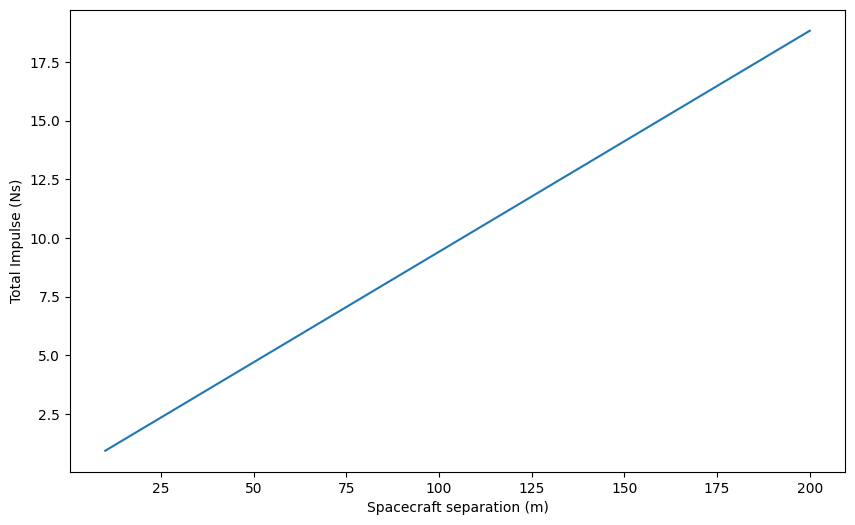

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(distances, total_impulse_map)
plt.xlabel("Spacecraft separation (m)")   
plt.ylabel("Total Impulse (Ns)")
plt.show()

In [27]:
r1_0, v1_0, r2_0, v2_0, orbital_normal_vector = make_initial_conditions_face_gc(orbit_inclination, 68.48)

body1 = Body(M_oculus, r1_0.copy(), v1_0.copy())
body2 = Body(M_lux, r2_0.copy(), v2_0.copy())

plot_sim = Simulation(body1, body2, dt, N_steps, compute_perturbed_acceleration)
plot_sim.run(trim_start=4)

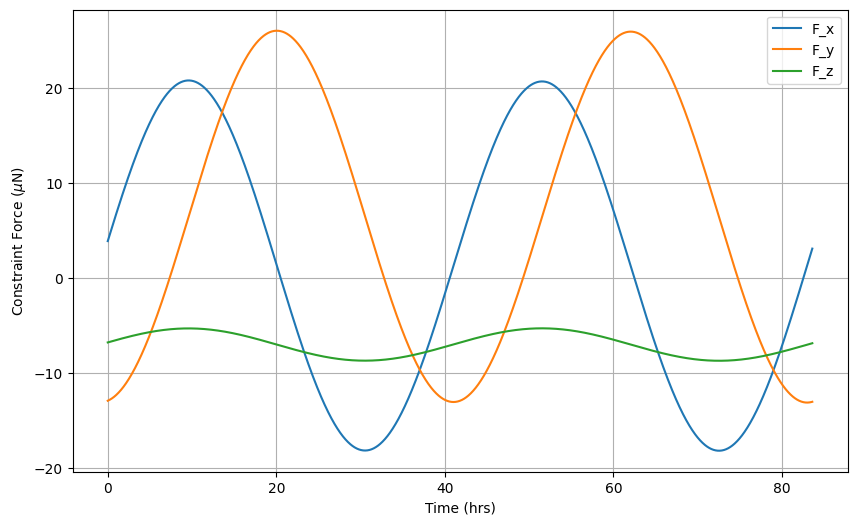

In [45]:
plt.figure(figsize=(10, 6))

t = np.arange(len(plot_sim.f2_constraint)) * plot_sim.dt
F = plot_sim.f2_constraint

plt.plot(t/3600, F[:, 0]*1e6, label='F_x')
plt.plot(t/3600, F[:, 1]*1e6, label='F_y')
plt.plot(t/3600, F[:, 2]*1e6, label='F_z')
#plt.plot(t, np.linalg.norm(F, axis=1), label='|F|', linewidth=2)

plt.xlabel('Time (hrs)')
plt.ylabel(r'Constraint Force ($\mu$N)')
plt.legend()
plt.grid(True)
plt.show()

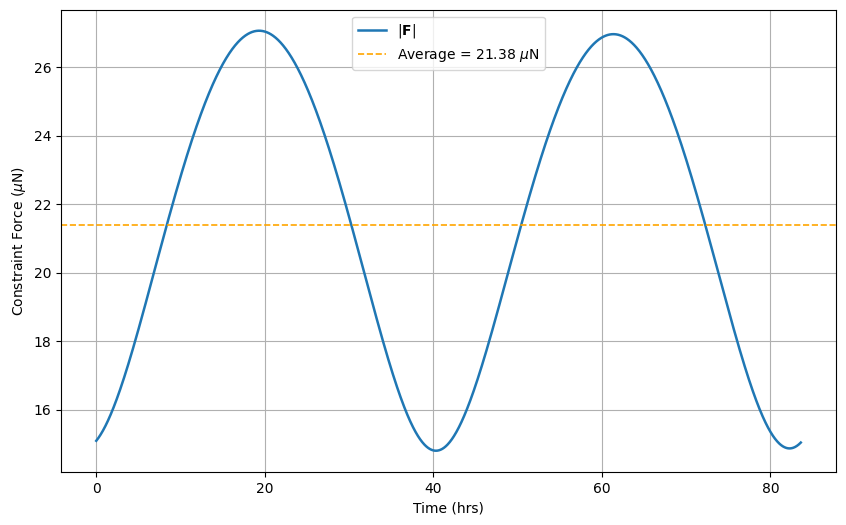

In [ ]:
plt.figure(figsize=(10, 6))

t = np.arange(len(plot_sim.f2_constraint)) * plot_sim.dt
F = plot_sim.f2_constraint
F_mag = np.linalg.norm(F, axis=1) * 1e6
F_avg = np.mean(F_mag)

plt.plot(t/3600, F_mag, linewidth=1.8, label=r'$|\mathbf{F}|$')
plt.axhline(F_avg, color='orange', linestyle='--', linewidth=1.2,
            label=fr'Average = {F_avg:.2f} $\mu$N')

plt.xlabel('Time (hrs)')
plt.ylabel(r'Constraint Force ($\mu$N)')
plt.legend()
plt.grid(True)
plt.show()

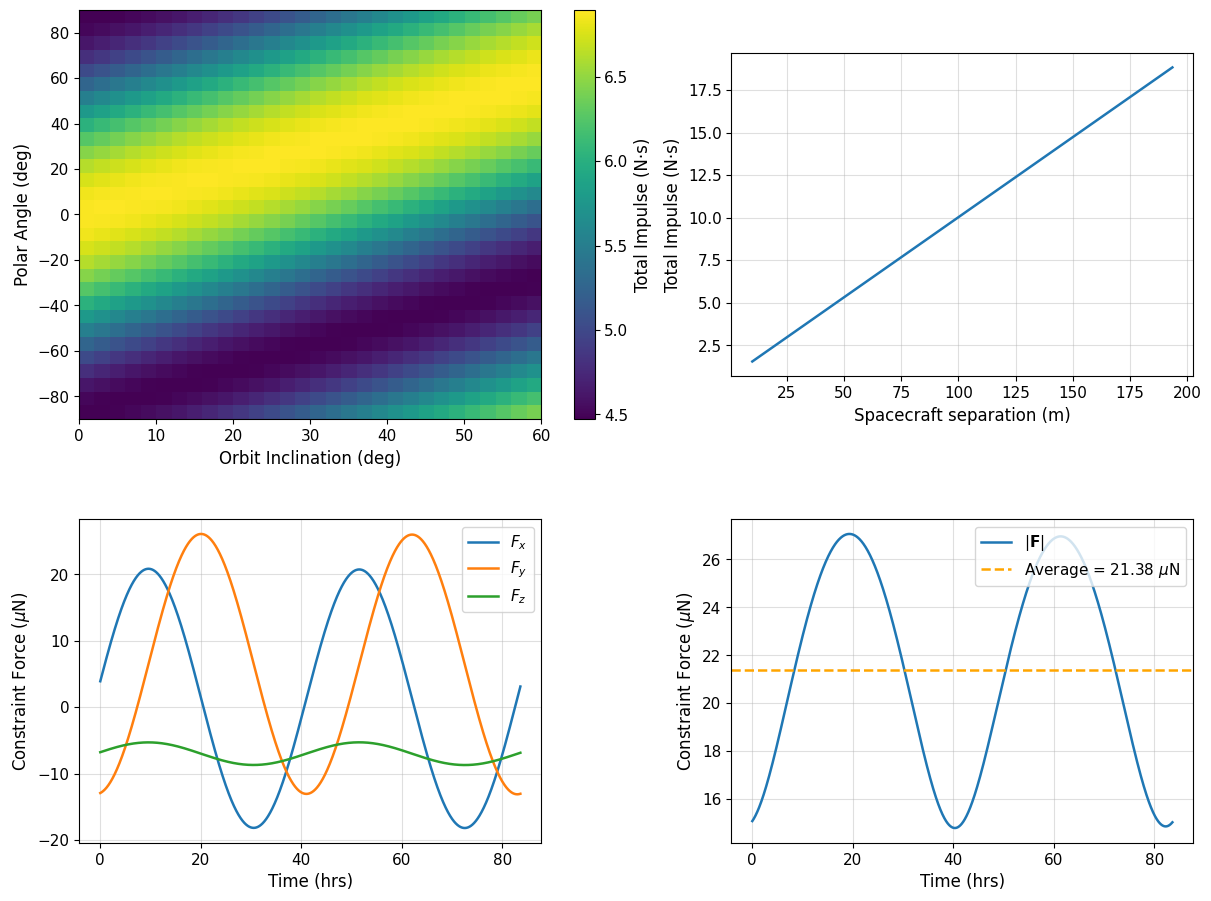

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Read input files explicitly
# ----------------------------
heatmap_file = "total_impulse_map_20260506_170345.csv"
distance_file = "total_impulse_distance_dependency_20260506_174617.csv"

# Heatmap CSV:
# assumed to contain only the 2D impulse map values
total_impulse_map = pd.read_csv(heatmap_file, header=None).values

# Distance dependency CSV:
# assumed columns are [distance, total_impulse]
distance_df = pd.read_csv(distance_file)

# If your CSV has no header, use this instead:
# distance_df = pd.read_csv(distance_file, header=None)
# distance_df.columns = ["distance", "total_impulse"]

distances = np.linspace(10, 200, Map_resolution)
total_impulse_distance = distance_df.iloc[:, 0].to_numpy()

# ----------------------------
# Force data
# ----------------------------
t = np.arange(len(plot_sim.f2_constraint)) * plot_sim.dt
F = plot_sim.f2_constraint
F_mag = np.linalg.norm(F, axis=1) * 1e6
F_avg = np.mean(F_mag)

# ----------------------------
# Global plot style
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# 1.1 Heatmap
im = axs[0, 0].imshow(
    total_impulse_map,
    extent=[0, 60, -90, 90],
    origin="lower",
    aspect="auto"
)
axs[0, 0].set_xlabel("Orbit Inclination (deg)")
axs[0, 0].set_ylabel("Polar Angle (deg)")
cbar = fig.colorbar(im, ax=axs[0, 0])
cbar.set_label("Total Impulse (N·s)")

# 1.2 Distance dependency
axs[0, 1].plot(distances[:-1], total_impulse_distance, color="C0", linewidth=1.8)
axs[0, 1].set_xlabel("Spacecraft separation (m)")
axs[0, 1].set_ylabel("Total Impulse (N·s)")
axs[0, 1].grid(True, alpha=0.4)

# 2.1 Force components
axs[1, 0].plot(t / 3600, F[:, 0] * 1e6, label=r"$F_x$", linewidth=1.8)
axs[1, 0].plot(t / 3600, F[:, 1] * 1e6, label=r"$F_y$", linewidth=1.8)
axs[1, 0].plot(t / 3600, F[:, 2] * 1e6, label=r"$F_z$", linewidth=1.8)
axs[1, 0].set_xlabel("Time (hrs)")
axs[1, 0].set_ylabel(r"Constraint Force ($\mu$N)")
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.4)

# 2.2 Force magnitude
axs[1, 1].plot(t / 3600, F_mag, color="C0", linewidth=1.8, label=r"$|\mathbf{F}|$")
axs[1, 1].axhline(
    F_avg,
    color="orange",
    linestyle="--",
    linewidth=1.8,
    label=fr"Average = {F_avg:.2f} $\mu$N"
)
axs[1, 1].set_xlabel("Time (hrs)")
axs[1, 1].set_ylabel(r"Constraint Force ($\mu$N)")
axs[1, 1].legend(loc=1)
axs[1, 1].grid(True, alpha=0.4)

# Optional: make subplot box ratios match visually
for ax in [axs[0, 1], axs[1, 0], axs[1, 1]]:
    ax.set_box_aspect(0.7)

plt.show()